# Wav2vec2

## Wav2vec2 fine-tuning on SEND audio to predict affective valence

In [1]:
import os
import pandas as pd
import numpy as np
from transformers import Wav2Vec2FeatureExtractor
from model_send_audio import preprocess_audio_data, load_audio_inputs, run_wav2vec2

### 1. Preprocess audio inputs

#### Supplementary Table 8

Preprocess data from the Stanford Emotional Narratives Dataset (SEND). Data (not included in this repo) were collected and annotated as described in Ong et al. (2021), and were provided by Dr. Ong to be used in accordance with the end-user license agreement. The subset of the data with available video clips are preprocessed into audio inputs that can be used to fine-tune an audio-based model. Models are fine-tuned to predict the labels for affective valence in the SEND dataset averaged within 10-, 20-, and 30-second windows. The original splits for train, validation, and test sets in the Ong et al. paper are preserved here.

In [2]:
segment_duration_levels = [30, 20, 10]

In [3]:
data = {}
for segment_duration in segment_duration_levels:
    data[segment_duration] = preprocess_audio_data("data/raw/with-video/videos", "data/raw/ratings", 
                                                   segment_duration, sampling_rate=16000, 
                                                   splits=["train", "valid", "test"])

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 265

VALID SPLIT
Number of clips: 137

TEST SPLIT
Number of clips: 161

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 385

VALID SPLIT
Number of clips: 196

TEST SPLIT
Number of clips: 233

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------
TRAIN SPLIT
Number of clips: 741

VALID SPLIT
Number of clips: 379

TEST SPLIT
Number of clips: 452



### 2. Specify training parameters

Input data are segmented over different time windows (10-, 20-, and 30-second segments). Hyperparameters tuned here are dropout levels.

In [4]:
model_name = "wav2vec2-base" 
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(f"facebook/{model_name}")
n_epochs_levels = [50] 
hidden_dropout_levels = [0]
actv_dropout_levels = [0, 0.1, 0.4]
attn_dropout_levels = [0, 0.1, 0.4]
final_dropout_levels = [0, 0.1, 0.4]
constant_params = {"lr": 0.00005, 
                   "tune_layer": 11, 
                   "batch_size": 1, 
                   "warmup_steps": 500,
                   "device": "mps:0"}

### 3. Train models over a range of hyperparameters

In [5]:
from datasets import Dataset, Features, Value, Sequence

In [6]:
def load_audio_inputs(data, segment_duration, feature_extractor, 
                      splits=["train", "valid"]):
    
    print("-"*100 + f"\n{segment_duration}-SECOND CLIPS\n" + "-"*100)
    
    def process(examples):
        return feature_extractor(examples["audio"], sampling_rate=feature_extractor.sampling_rate, return_tensors="pt")
    
    def dict_list_generator(data_dict):
        num_examples = len(next(iter(data_dict.values())))
        for i in range(num_examples):
            yield {key: data_dict[key][i] for key in data_dict}
    
    features = Features({
        "id": Value("string"),
        "audio": Sequence(Value("float64")),
        "path": Value("string"),
        "label": Value("float64")
    })
    
    inputs = {}
    for split in splits:
        ds = Dataset.from_generator(dict_list_generator, 
                                    gen_kwargs={"data_dict": data[split]},
                                    features=features)
        inputs[split] = ds.map(process, batched=True)      
    
    print("\n" + "-"*100 + "\n")
    
    return inputs

In [7]:
validation = []

for segment_duration in segment_duration_levels:

    inputs = load_audio_inputs(data[segment_duration], segment_duration, feature_extractor, 
                             splits=["train", "valid"])

    for n_epochs in n_epochs_levels:
        for hidden_dropout in hidden_dropout_levels:
            for actv_dropout in actv_dropout_levels:
                for attn_dropout in attn_dropout_levels:
                    for final_dropout in final_dropout_levels:
        
                        try:
                            model_path, model_eval = run_wav2vec2(model_name,
                                                                  inputs,
                                                                  n_epochs=n_epochs,
                                                                  segment_duration=segment_duration,
                                                                  hidden_dropout=hidden_dropout,
                                                                  actv_dropout=actv_dropout, 
                                                                  attn_dropout=attn_dropout,
                                                                  final_dropout=final_dropout,
                                                                  **constant_params,
                                                                  splits=["train", "valid"],
                                                                  plot=False)
                        except:
                            print("Error training model")
                    
                    validation += model_eval  
                    validation_df = pd.DataFrame(validation)
                    validation_df.to_csv(f"tables/{model_name}_validation.csv", index=False)

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/wav2vec2-base/wav2vec2-base_30s_epochs50_lr5e-05_drop-hidden0_drop-actv0_drop-attn0_drop-final0_tune11

EVALUATING MODEL


TRAIN   Mean: 0.56114   SD: 0.16521   RMSE: 0.14090   R: 0.78667 (p=0.00000)   CCC: 0.74829 (p=0.00000)


VALID   Mean: 0.55861   SD: 0.18439   RMSE: 0.24595   R: 0.28600 (p=0.00070)   CCC: 0.27803 (p=0.00000)

----------------------------------------------------------------------------------------------------



...

VALID   Mean: 0.53964   SD: 0.24396   RMSE: 0.29902   R: 0.17802 (p=0.00050)   CCC: 0.17621 (p=0.00000)

----------------------------------------------------------------------------------------------------



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/wav2vec2-base/wav2vec2-base_10s_epochs50_lr5e-05_drop-hidden0_drop-actv0.4_drop-attn0.4_drop-final0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.54493   SD: 0.23257   RMSE: 0.26772   R: 0.33378 (p=0.00000)   CCC: 0.33365 (p=0.00000)


VALID   Mean: 0.53965   SD: 0.24396   RMSE: 0.29902   R: 0.17801 (p=0.00050)   CCC: 0.17621 (p=0.00000)

----------------------------------------------------------------------------------------------------



### 4. Select model by validation set performance

In [8]:
df = pd.read_csv(f"results/{model_name}_validation.csv", index_col=None)
df.head()

,path,split,segment_duration,n_epochs,lr,hidden_dropout,actv_dropout,attn_dropout,final_dropout,tune_layer,pred_mean,pred_sd,rmse,r,r_p,ccc,ccc_p
0,models/30s/wav2vec2-base/wav2vec2-base_30s_epo...,train,30,50,0.00005,0,0.0,0.0,0.4,11,0.557291,0.164131,0.139698,0.791322,3.941146e-58,0.751390,0.0
1,models/30s/wav2vec2-base/wav2vec2-base_30s_epo...,valid,30,50,0.00005,0,0.0,0.0,0.4,11,0.556239,0.182336,0.248123,0.264745,1.769952e-03,0.257251,0.0
2,models/30s/wav2vec2-base/wav2vec2-base_30s_epo...,train,30,50,0.00005,0,0.0,0.1,0.4,11,0.563216,0.164369,0.142225,0.782274,5.439163e-56,0.742716,0.0
3,models/30s/wav2vec2-base/wav2vec2-base_30s_epo...,valid,30,50,0.00005,0,0.0,0.1,0.4,11,0.565472,0.184794,0.252237,0.254746,2.663451e-03,0.246326,0.0
4,models/30s/wav2vec2-base/wav2vec2-base_30s_epo...,train,30,50,0.00005,0,0.0,0.4,0.4,11,0.563879,0.170466,0.141958,0.781763,7.132754e-56,0.750195,0.0


In [9]:
valid_params = {}
for segment_duration in segment_duration_levels:
    
    segment_df = df[df["segment_duration"] == segment_duration]
    top_df = segment_df[segment_df["split"] == "valid"].sort_values("ccc", ascending=False)
    top_dict = top_df.to_dict(orient="records")[0]
    
    valid_params[segment_duration] = {"n_epochs": top_dict["n_epochs"],
                                      "hidden_dropout": top_dict["hidden_dropout"],
                                      "actv_dropout": top_dict["actv_dropout"],
                                      "attn_dropout": top_dict["attn_dropout"],
                                      "final_dropout": top_dict["final_dropout"],}
    
    print("-"*100 + f"\nTOP MODELS FOR {segment_duration}-SECOND SEGMENTS")
    print(top_df[["n_epochs", "actv_dropout", "attn_dropout", "ccc", "ccc_p"]])
    print()

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 30-SECOND SEGMENTS
    n_epochs  actv_dropout  attn_dropout       ccc  ccc_p
11        50           0.1           0.4  0.262049  0.000
5         50           0.0           0.4  0.258659  0.000
1         50           0.0           0.0  0.257251  0.000
3         50           0.0           0.1  0.246326  0.000
9         50           0.1           0.1  0.245935  0.000
7         50           0.1           0.0  0.235480  0.002
17        50           0.4           0.4  0.176782  0.000
15        50           0.4           0.1  0.175386  0.000
13        50           0.4           0.0  0.165828  0.000

----------------------------------------------------------------------------------------------------
TOP MODELS FOR 20-SECOND SEGMENTS
    n_epochs  actv_dropout  attn_dropout       ccc  ccc_p
23        50           0.0           0.4  0.243449  0.001
29        50           0.1       

### 5. Evaluate model on the test set

#### Supplementary Tables 9-10

----------------------------------------------------------------------------------------------------
30-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/30s/wav2vec2-base/wav2vec2-base_30s_epochs50_lr5e-05_drop-hidden0_drop-actv0.1_drop-attn0.4_drop-final0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.54008   SD: 0.19172   RMSE: 0.16827   R: 0.69224 (p=0.00000)   CCC: 0.68037 (p=0.00000)


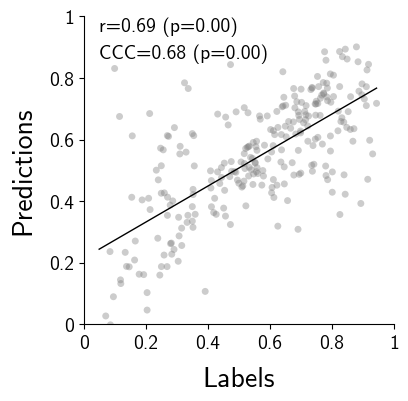

VALID   Mean: 0.52222   SD: 0.19198   RMSE: 0.25142   R: 0.26469 (p=0.00177)   CCC: 0.26205 (p=0.00000)


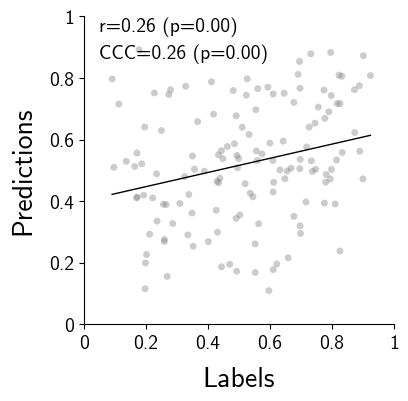

TEST    Mean: 0.58383   SD: 0.13040   RMSE: 0.24452   R: 0.13592 (p=0.08559)   CCC: 0.11543 (p=0.04800)


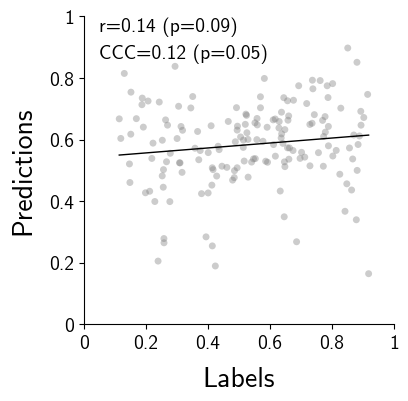


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
20-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/20s/wav2vec2-base/wav2vec2-base_20s_epochs50_lr5e-05_drop-hidden0_drop-actv0_drop-attn0.4_drop-final0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.59082   SD: 0.18676   RMSE: 0.17939   R: 0.66276 (p=0.00000)   CCC: 0.63868 (p=0.00000)


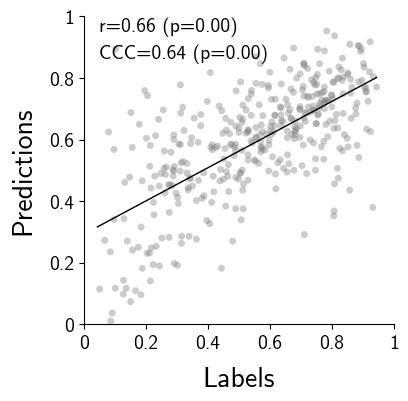

VALID   Mean: 0.57044   SD: 0.19193   RMSE: 0.25768   R: 0.25235 (p=0.00036)   CCC: 0.24345 (p=0.00100)


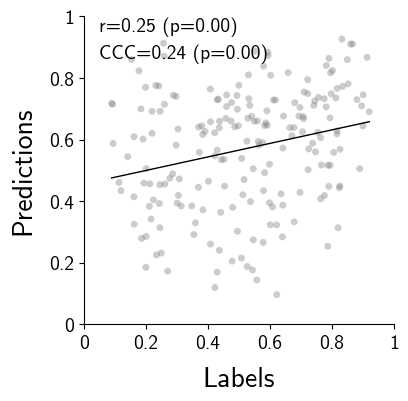

TEST    Mean: 0.59618   SD: 0.14706   RMSE: 0.26151   R: 0.07133 (p=0.27822)   CCC: 0.06291 (p=0.16400)


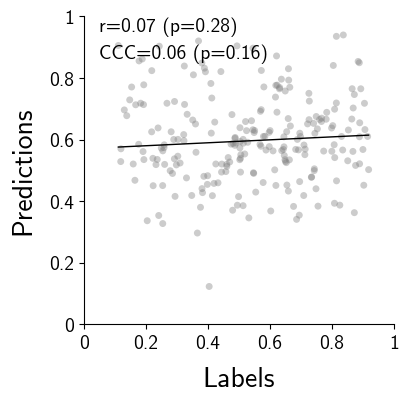


----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
10-SECOND CLIPS
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



FOUND MODEL
Path: models/10s/wav2vec2-base/wav2vec2-base_10s_epochs50_lr5e-05_drop-hidden0_drop-actv0.4_drop-attn0.4_drop-final0.4_tune11

EVALUATING MODEL


TRAIN   Mean: 0.54493   SD: 0.23257   RMSE: 0.26772   R: 0.33378 (p=0.00000)   CCC: 0.33365 (p=0.00000)


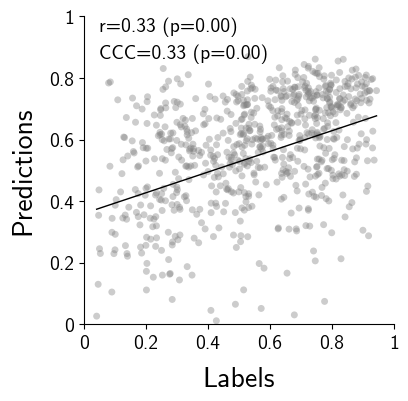

VALID   Mean: 0.53965   SD: 0.24396   RMSE: 0.29902   R: 0.17801 (p=0.00050)   CCC: 0.17621 (p=0.00000)


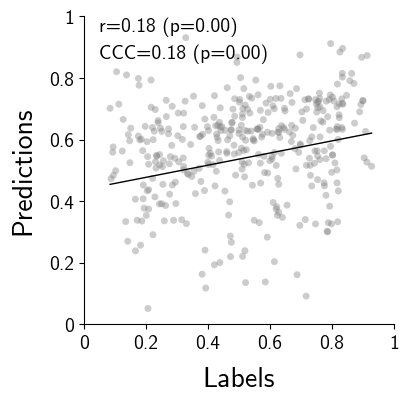

TEST    Mean: 0.49412   SD: 0.29355   RMSE: 0.36165   R: 0.03550 (p=0.45157)   CCC: 0.03359 (p=0.22100)


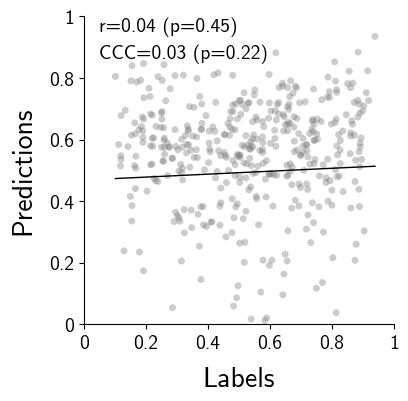


----------------------------------------------------------------------------------------------------



In [10]:
evaluation = []
for segment_duration in segment_duration_levels:
    
    inputs = load_audio_inputs(data[segment_duration], segment_duration, feature_extractor, 
                               splits=["train", "valid", "test"])
    
    model_path, model_eval = run_wav2vec2(model_name, 
                                          inputs,
                                          segment_duration=segment_duration,
                                          n_epochs=valid_params[segment_duration]["n_epochs"],
                                          hidden_dropout=valid_params[segment_duration]["hidden_dropout"],
                                          actv_dropout=valid_params[segment_duration]["actv_dropout"],
                                          attn_dropout=valid_params[segment_duration]["attn_dropout"],
                                          final_dropout=valid_params[segment_duration]["final_dropout"],
                                          **constant_params,
                                          splits=["train", "valid", "test"],
                                          plot=True)

    evaluation += model_eval

evaluation_df = pd.DataFrame(evaluation)
evaluation_df.to_csv(f"tables/{model_name}_evaluation.csv", index=False)